In [1]:
1+2

3

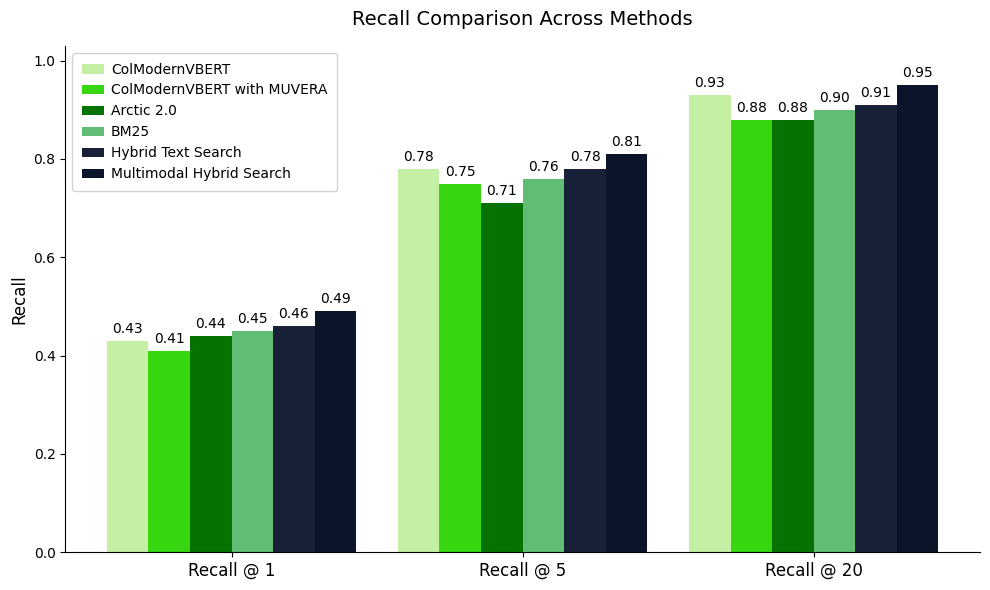

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data
metrics = ["Recall @ 1", "Recall @ 5", "Recall @ 20"]  # Keep all metrics for data reference
categories = [
    "ColModernVBERT", 
    "ColModernVBERT with MUVERA", 
    "Arctic 2.0", 
    "BM25", 
    "Hybrid Text Search", 
    "Multimodal Hybrid Search"
]
recall_at_1 = [0.43, 0.41, 0.44, 0.45, 0.46, 0.49]
recall_at_5 = [0.78, 0.75, 0.71, 0.76, 0.78, 0.81]
recall_at_20 = [0.93, 0.88, 0.88, 0.90, 0.91, 0.95]

# Include Recall @ 1, Recall @ 5, and Recall @ 20
plot_metrics = ["Recall @ 1", "Recall @ 5", "Recall @ 20"]
x = np.arange(len(plot_metrics))  # 0 ('Recall @ 1'), 1 ('Recall @ 5'), 2 ('Recall @ 20')

n_categories = len(categories)
width = 1.0 / (n_categories + 1)  # make bars fill the group spacing, with a little padding

fig, ax = plt.subplots(figsize=(10, 6))

bars = []
# No spacing (no bar_gap) - set positions so that bars touch within each group

group_total_width = n_categories * width  # No bar_gap

for i, (cat, color) in enumerate(zip(
    categories,
    ["#C5EFA4", "#38D611", "#057201", "#61BD73", "#172037", "#0C1429"]
)):
    values = [recall_at_1[i], recall_at_5[i], recall_at_20[i]]
    bar_positions = x - group_total_width/2 + i * width + width/2
    bar = ax.bar(
        bar_positions,
        values,
        width,
        label=cat,
        color=color
    )
    bars.append(bar)

# Add labels
def add_bar_labels(bar_group):
    for bar in bar_group:
        for rect in bar:
            height = rect.get_height()
            ax.text(
                rect.get_x() + rect.get_width()/2,
                height + 0.01,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

for bar in bars:
    add_bar_labels([bar])

ticklabel_kwargs = {"fontsize": 12}

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics, **ticklabel_kwargs)
ax.set_ylabel("Recall", fontsize=12)
# Unbold the title by specifying fontweight="normal"
ax.set_title("Recall Comparison Across Methods", fontsize=14, pad=15, fontweight="normal")
ax.set_ylim(0, 1.03)

legend_prop = {"size": 10}

ax.legend(
    fontsize=10,
    loc='upper left',
    frameon=True,
    framealpha=0.85,
    borderpad=0.7,
    labelspacing=0.5,
    handlelength=1.6,
    handletextpad=0.5,
    fancybox=True,
    edgecolor="#cccccc",
    prop=legend_prop
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("irpapers-recall.png", dpi=1000)
plt.show()

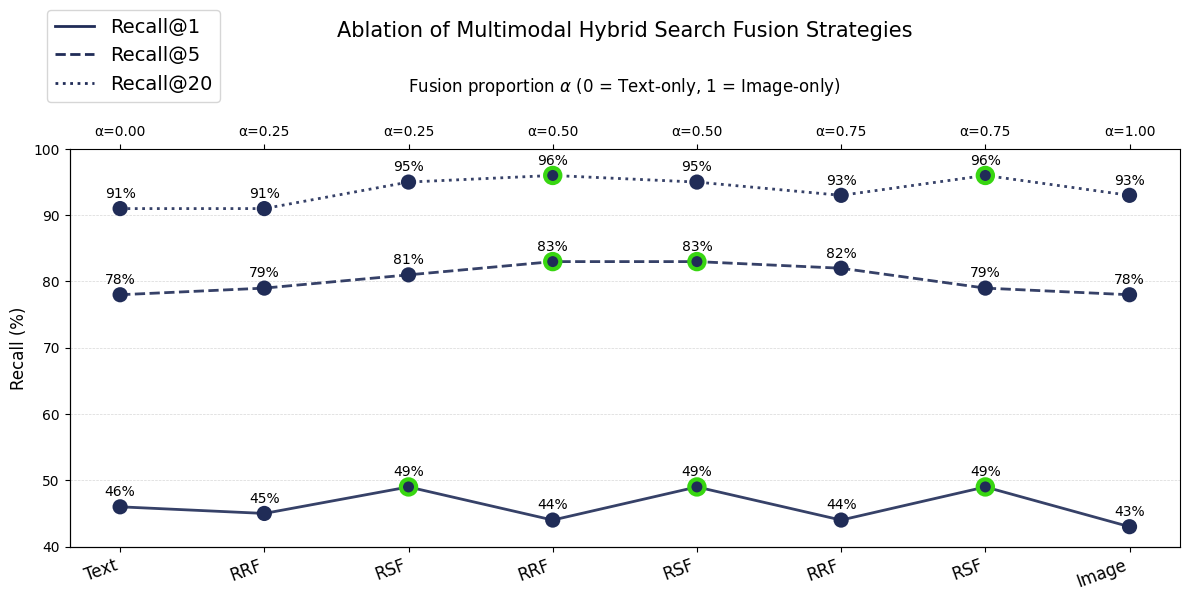

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Data from the table
methods = [
    "Hybrid Arctic 2.0 + BM25 (Text)",
    "Reciprocal Rank Fusion (0.25)",
    "Relative Score Fusion (0.25)",
    "Reciprocal Rank Fusion (0.50)",
    "Relative Score Fusion (0.50)",
    "Reciprocal Rank Fusion (0.75)",
    "Relative Score Fusion (0.75)",
    "ColModernVBERT (Image)"
]

fusion_categories = [
    "Text", 
    "RRF",
    "RSF",
    "RRF", 
    "RSF",
    "RRF",
    "RSF",
    "Image"
]

alphas = [0.0, 0.25, 0.25, 0.5, 0.5, 0.75, 0.75, 1.0]

recall_1  = [46, 45, 49, 44, 49, 44, 49, 43]
recall_5  = [78, 79, 81, 83, 83, 82, 79, 78]
recall_20 = [91, 91, 95, 96, 95, 93, 96, 93]

# Identify best values for highlights
best_r1 = max(recall_1)
best_r5 = max(recall_5)
best_r20 = max(recall_20)

x = np.arange(len(methods))  # X locations

fig, ax = plt.subplots(figsize=(12, 6))

# Use single dark blue for all lines and points
point_line_color = "#202c57"  # Example: dark blue

# Different line styles for each recall series
linestyles = ["-", "--", ":"]  # Solid, dashed, dotted

# NO offsets for points or lines -- give exactly at x values so all dots are vertically centered/aligned
# Fixed: Make sure all x-coordinates for different recall series are exactly the same (x)
labels = ["Recall@1", "Recall@5", "Recall@20"]
recalls = [recall_1, recall_5, recall_20]
sizes = [120, 120, 120]

# For highlighting points with best values (draw bright green edge color)
def get_edgecolors(values, best):
    return ["#38d611" if v == best else point_line_color for v in values]
def get_linewidths(values, best):
    return [3 if v == best else 0 for v in values]

# Draw lines between points using different linestyles, all data at same `x` (NO OFFSETS)
for rec, linestyle in zip(recalls, linestyles):
    ax.plot(
        x,
        rec,
        color=point_line_color,
        alpha=0.9,
        linewidth=2,
        zorder=2,
        marker=None,
        linestyle=linestyle
    )

# Plot the scatter points -- all in dark blue, but with green edge highlighting, all directly at x locations (NO OFFSETS)
scs = []
for i, (rec, label, size, linestyle) in enumerate(zip(recalls, labels, sizes, linestyles)):
    edgecolors = get_edgecolors(rec, max(rec))
    linewidths = get_linewidths(rec, max(rec))
    sc = ax.scatter(
        x, rec, 
        c=point_line_color,
        s=size,
        label=label,
        zorder=3+i,
        edgecolors=edgecolors,
        linewidths=linewidths
    )
    # Annotate points
    for xi, yi in zip(x, rec):
        ax.text(
            xi, yi + 1.2, f"{yi}%", ha="center", va="bottom", fontsize=10
        )
    scs.append(sc)

# Add a vertical line behind each x to ensure no visual offset
for xi in x:
    ax.axvline(x=xi, color='none') # invisible, ensures ticks are at integers exactly

# Show alpha on a twin x-axis
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(x)
ax2.set_xticklabels([f"α={a:.2f}" for a in alphas], fontsize=10, rotation=0)
ax2.set_xlabel(
    r"Fusion proportion $\alpha$ (0 = Text-only, 1 = Image-only)",
    fontsize=12, 
    labelpad=24  # Increase labelpad/margin below the xlabel
)

ax.set_xticks(x)
ax.set_xticklabels(fusion_categories, rotation=20, ha="right", fontsize=12)
ax.set_ylabel("Recall (%)", fontsize=12)
ax.set_ylim(40, 100)

# Add vertical bottom spacing: Make the axes "taller" inside the figure by using subplots_adjust(bottom=...)
# Also increase the title's 'pad'
ax.set_title("Ablation of Multimodal Hybrid Search Fusion Strategies", fontsize=15, pad=28)

legend_elements = [
    Line2D([0], [0], color=point_line_color, linestyle=linestyles[0], linewidth=2, label="Recall@1"),
    Line2D([0], [0], color=point_line_color, linestyle=linestyles[1], linewidth=2, label="Recall@5"),
    Line2D([0], [0], color=point_line_color, linestyle=linestyles[2], linewidth=2, label="Recall@20"),
]

# Move the legend to top left, outside the plot, and increase the vertical offset above plot, then adjust bottom for plot spacing
ax.legend(
    handles=legend_elements,
    fontsize=14,
    loc='upper left',
    frameon=True,
    bbox_to_anchor=(-0.02, 1.35),  # Move further above axes
    borderaxespad=0.0
)

# Grid and style
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.subplots_adjust(bottom=0.3)  # make more space below the axes, moving plot upwards
plt.tight_layout()
plt.savefig("multimodal.png", dpi=1000)  # Save the figure to the required file
plt.show()


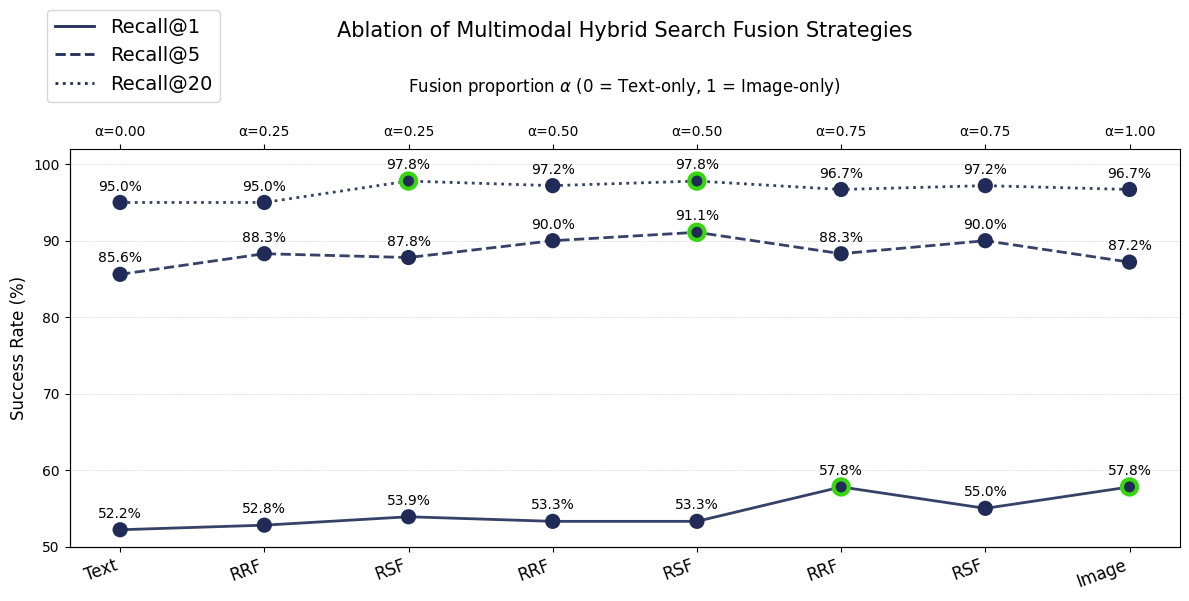

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Data from the LaTeX table
methods = [
    "Hybrid Voyage 3 Large + BM25 (Text)",
    "Reciprocal Rank Fusion (0.25)",
    "Relative Score Fusion (0.25)",
    "Reciprocal Rank Fusion (0.50)",
    "Relative Score Fusion (0.50)",
    "Reciprocal Rank Fusion (0.75)",
    "Relative Score Fusion (0.75)",
    "Cohere Embed v4.0 (Image)"
]

fusion_categories = [
    "Text", 
    "RRF",
    "RSF",
    "RRF", 
    "RSF",
    "RRF",
    "RSF",
    "Image"
]

alphas = [0.0, 0.25, 0.25, 0.5, 0.5, 0.75, 0.75, 1.0]

# S@1, S@5, S@20 values from the table
recall_1  = [52.2, 52.8, 53.9, 53.3, 53.3, 57.8, 55.0, 57.8]
recall_5  = [85.6, 88.3, 87.8, 90.0, 91.1, 88.3, 90.0, 87.2]
recall_20 = [95.0, 95.0, 97.8, 97.2, 97.8, 96.7, 97.2, 96.7]

# Identify best values for highlights
best_r1 = max(recall_1)
best_r5 = max(recall_5)
best_r20 = max(recall_20)

x = np.arange(len(methods))  # X locations

fig, ax = plt.subplots(figsize=(12, 6))

# Use single dark blue for all lines and points
point_line_color = "#202c57"

# Different line styles for each recall series
linestyles = ["-", "--", ":"]  # Solid, dashed, dotted

labels = ["Recall@1", "Recall@5", "Recall@20"]
recalls = [recall_1, recall_5, recall_20]
sizes = [120, 120, 120]

# For highlighting points with best values (draw bright green edge color)
def get_edgecolors(values, best):
    return ["#38d611" if v == best else point_line_color for v in values]

def get_linewidths(values, best):
    return [3 if v == best else 0 for v in values]

# Draw lines between points using different linestyles
for rec, linestyle in zip(recalls, linestyles):
    ax.plot(
        x,
        rec,
        color=point_line_color,
        alpha=0.9,
        linewidth=2,
        zorder=2,
        marker=None,
        linestyle=linestyle
    )

# Plot the scatter points with green edge highlighting for best values
scs = []
for i, (rec, label, size, linestyle) in enumerate(zip(recalls, labels, sizes, linestyles)):
    edgecolors = get_edgecolors(rec, max(rec))
    linewidths = get_linewidths(rec, max(rec))
    sc = ax.scatter(
        x, rec, 
        c=point_line_color,
        s=size,
        label=label,
        zorder=3+i,
        edgecolors=edgecolors,
        linewidths=linewidths
    )
    # Annotate points
    for xi, yi in zip(x, rec):
        ax.text(
            xi, yi + 1.2, f"{yi}%", ha="center", va="bottom", fontsize=10
        )
    scs.append(sc)

# Show alpha on a twin x-axis
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(x)
ax2.set_xticklabels([f"α={a:.2f}" for a in alphas], fontsize=10, rotation=0)
ax2.set_xlabel(
    r"Fusion proportion $\alpha$ (0 = Text-only, 1 = Image-only)",
    fontsize=12, 
    labelpad=24
)

ax.set_xticks(x)
ax.set_xticklabels(fusion_categories, rotation=20, ha="right", fontsize=12)
ax.set_ylabel("Success Rate (%)", fontsize=12)
ax.set_ylim(50, 102)

ax.set_title("Ablation of Multimodal Hybrid Search Fusion Strategies", fontsize=15, pad=28)

legend_elements = [
    Line2D([0], [0], color=point_line_color, linestyle=linestyles[0], linewidth=2, label="Recall@1"),
    Line2D([0], [0], color=point_line_color, linestyle=linestyles[1], linewidth=2, label="Recall@5"),
    Line2D([0], [0], color=point_line_color, linestyle=linestyles[2], linewidth=2, label="Recall@20"),
]

ax.legend(
    handles=legend_elements,
    fontsize=14,
    loc='upper left',
    frameon=True,
    bbox_to_anchor=(-0.02, 1.35),
    borderaxespad=0.0
)

# Grid and style
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.savefig("multimodal-2.png", dpi=1000)
plt.show()

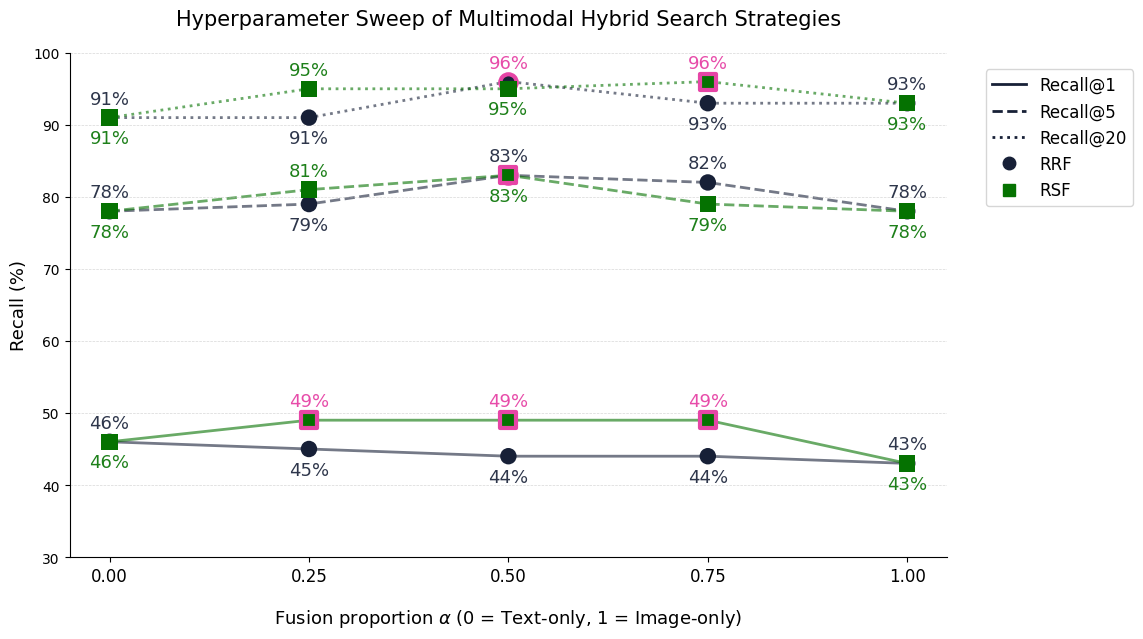

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# ---- Data ----
alphas = np.array([0.00, 0.25, 0.50, 0.75, 1.00])

text_only = dict(r1=46, r5=78, r20=91)
image_only = dict(r1=43, r5=78, r20=93)

rrf = {
    0.25: dict(r1=45, r5=79, r20=91),
    0.50: dict(r1=44, r5=83, r20=96),
    0.75: dict(r1=44, r5=82, r20=93),
}
rsf = {
    0.25: dict(r1=49, r5=81, r20=95),
    0.50: dict(r1=49, r5=83, r20=95),
    0.75: dict(r1=49, r5=79, r20=96),
}

def build_series(method_dict, key):
    ys = []
    for a in alphas:
        if a == 0.0:
            ys.append(text_only[key])
        elif a == 1.0:
            ys.append(image_only[key])
        else:
            ys.append(method_dict[float(a)][key])
    return np.array(ys, dtype=float)

rrf_r1, rrf_r5, rrf_r20 = (build_series(rrf, "r1"), build_series(rrf, "r5"), build_series(rrf, "r20"))
rsf_r1, rsf_r5, rsf_r20 = (build_series(rsf, "r1"), build_series(rsf, "r5"), build_series(rsf, "r20"))

# ---- Styling ----
rrf_color = "#172037"  # dark blue for RRF "#172037", "#0C1429"]
rsf_color = "#057201"  # green for RSF #38d611 #057201
highlight_color = "#e645a6"  # pink highlight #e645a6

recall_series = [
    ("Recall@1",  rrf_r1,  rsf_r1,  "-",  140),
    ("Recall@5",  rrf_r5,  rsf_r5,  "--", 140),
    ("Recall@20", rrf_r20, rsf_r20, ":",  140),
]

marker_rrf = "o"
marker_rsf = "s"

fig, ax = plt.subplots(figsize=(11.5, 6.5))

# Only highlight the overall best alpha for each recall, regardless of method
def best_point_highlights(rrf_vals, rsf_vals):
    """
    For a recall series (rrf_vals, rsf_vals), find the overall best score,
    and only return highlight for that point (for either rrf or rsf).
    """
    values = np.concatenate([rrf_vals, rsf_vals])
    best_val = np.max(values)
    # Find all index/alpha/method pairs with best_val (in case of ties, highlight all)
    highlights = []
    for idx, (v_rrf, v_rsf) in enumerate(zip(rrf_vals, rsf_vals)):
        for method, val in (("rrf", v_rrf), ("rsf", v_rsf)):
            if val == best_val:
                highlights.append((idx, method))
    return highlights

score_fontsize = 13

for i, (label, y_rrf, y_rsf, linestyle, size) in enumerate(recall_series):
    # Draw lines
    ax.plot(alphas, y_rrf, color=rrf_color, alpha=0.6, linewidth=2, linestyle=linestyle, zorder=1)
    ax.plot(alphas, y_rsf, color=rsf_color, alpha=0.6, linewidth=2, linestyle=linestyle, zorder=1)

    # Determine which single point(s) (could be a tie) to highlight
    highlights = best_point_highlights(y_rrf, y_rsf)

    # Draw all RRF and RSF markers for this recall, but only highlight the best(s)
    for idx, a in enumerate(alphas):
        # Determine marker colors and edgecolors
        rrf_kwargs = dict(
            c=rrf_color, s=size, marker=marker_rrf,
            edgecolors="none", linewidths=0, zorder=3
        )
        rsf_kwargs = dict(
            c=rsf_color, s=size, marker=marker_rsf,
            edgecolors="none", linewidths=0, zorder=4
        )
        # Check if current (idx, method) is a highlight
        if (idx, "rrf") in highlights:
            rrf_kwargs.update(dict(edgecolors=highlight_color, linewidths=3))
        if (idx, "rsf") in highlights:
            rsf_kwargs.update(dict(edgecolors=highlight_color, linewidths=3))

        # Plot points
        ax.scatter([a], [y_rrf[idx]], **rrf_kwargs)
        ax.scatter([a], [y_rsf[idx]], **rsf_kwargs)

    # ---- Place always all scores (not only the best) for comparability ----
    for a, rrf_val, rsf_val in zip(alphas, y_rrf, y_rsf):
        # Stagger the texts for readability; top (= max) in highlight, the other in regular color
        if rrf_val == rsf_val:
            # Both equal, both small
            ax.text(
                a, rrf_val + 1.4, f"{int(rrf_val)}%",
                ha="center", va="bottom",
                fontsize=score_fontsize, color=rrf_color, alpha=0.9
            )
            ax.text(
                a, rsf_val - 1.6, f"{int(rsf_val)}%",
                ha="center", va="top",
                fontsize=score_fontsize, color=rsf_color, alpha=0.9
            )
        else:
            if rrf_val > rsf_val:
                ax.text(
                    a, rrf_val + 1.4, f"{int(rrf_val)}%",
                    ha="center", va="bottom",
                    fontsize=score_fontsize,
                    color=highlight_color if (np.argmax([rrf_val, rsf_val]) == 0 and (list(alphas).index(a), "rrf") in highlights) else rrf_color,
                    alpha=0.96 if (np.argmax([rrf_val, rsf_val]) == 0 and (list(alphas).index(a), "rrf") in highlights) else 0.9
                )
                ax.text(
                    a, rsf_val - 1.6, f"{int(rsf_val)}%",
                    ha="center", va="top",
                    fontsize=score_fontsize, color=rsf_color, alpha=0.9
                )
            else:
                ax.text(
                    a, rrf_val - 1.6, f"{int(rrf_val)}%",
                    ha="center", va="top",
                    fontsize=score_fontsize, color=rrf_color, alpha=0.9
                )
                ax.text(
                    a, rsf_val + 1.4, f"{int(rsf_val)}%",
                    ha="center", va="bottom",
                    fontsize=score_fontsize,
                    color=highlight_color if (np.argmax([rrf_val, rsf_val]) == 1 and (list(alphas).index(a), "rsf") in highlights) else rsf_color,
                    alpha=0.96 if (np.argmax([rrf_val, rsf_val]) == 1 and (list(alphas).index(a), "rsf") in highlights) else 0.9
                )

ax.set_xticks(alphas)
ax.set_xticklabels([f"{a:.2f}" for a in alphas], fontsize=12)
ax.set_xlabel(r"Fusion proportion $\alpha$ (0 = Text-only, 1 = Image-only)", fontsize=13, labelpad=16)
ax.set_ylabel("Recall (%)", fontsize=13)
ax.set_ylim(30, 100)
ax.set_title("Hyperparameter Sweep of Multimodal Hybrid Search Strategies", fontsize=15, pad=20)

legend = [
    Line2D([0], [0], color=rrf_color, linestyle="-",  linewidth=2, label="Recall@1"),
    Line2D([0], [0], color=rrf_color, linestyle="--", linewidth=2, label="Recall@5"),
    Line2D([0], [0], color=rrf_color, linestyle=":",  linewidth=2, label="Recall@20"),
    Line2D([0], [0], color=rrf_color, marker=marker_rrf, linestyle="None", markersize=9, label="RRF"),
    Line2D([0], [0], color=rsf_color, marker=marker_rsf, linestyle="None", markersize=9, label="RSF"),
]

# Place legend to the right, outside the plot area, but near the top right
ax.legend(
    handles=legend,
    loc="upper left",
    bbox_to_anchor=(1.025, 1.0),
    frameon=True,
    fontsize=12,
    borderaxespad=1.0
)

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.subplots_adjust(right=0.78)  # Leave space for the legend on the right
plt.tight_layout()
plt.savefig("hyperparameter_sweep_fusion_weights.png", dpi=1000)
plt.show()

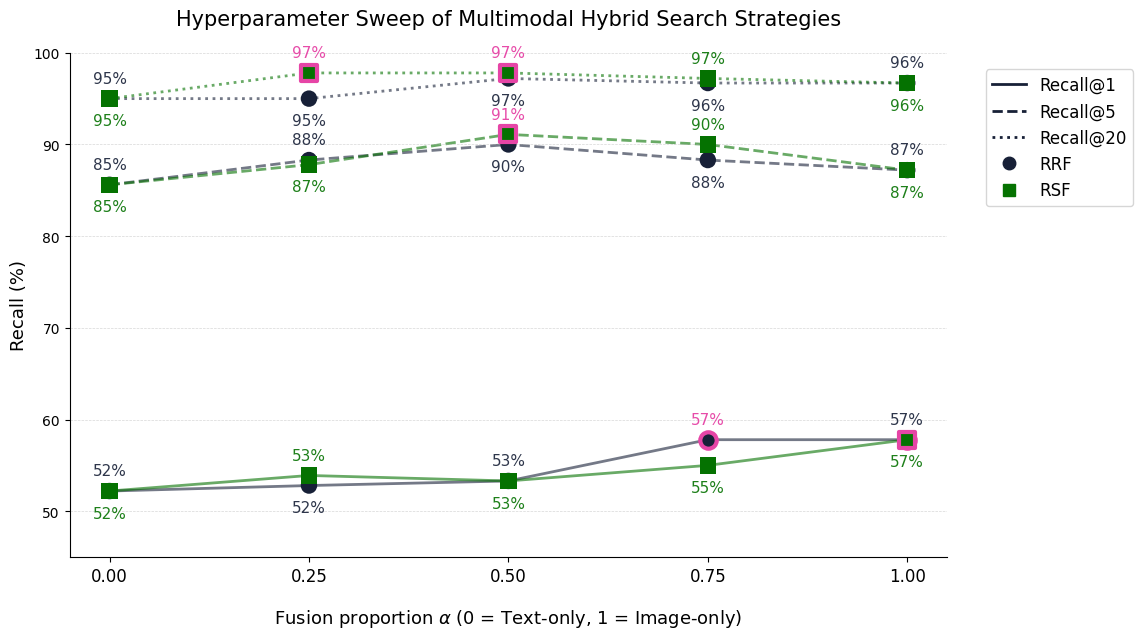

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# ---- Data ----
alphas = np.array([0.00, 0.25, 0.50, 0.75, 1.00])

text_only = dict(r1=52.2, r5=85.6, r20=95.0)
image_only = dict(r1=57.8, r5=87.2, r20=96.7)

rrf = {
    0.25: dict(r1=52.8, r5=88.3, r20=95.0),
    0.50: dict(r1=53.3, r5=90.0, r20=97.2),
    0.75: dict(r1=57.8, r5=88.3, r20=96.7),
}
rsf = {
    0.25: dict(r1=53.9, r5=87.8, r20=97.8),
    0.50: dict(r1=53.3, r5=91.1, r20=97.8),
    0.75: dict(r1=55.0, r5=90.0, r20=97.2),
}
def build_series(method_dict, key):
    ys = []
    for a in alphas:
        if a == 0.0:
            ys.append(text_only[key])
        elif a == 1.0:
            ys.append(image_only[key])
        else:
            ys.append(method_dict[float(a)][key])
    return np.array(ys, dtype=float)

rrf_r1, rrf_r5, rrf_r20 = (build_series(rrf, "r1"), build_series(rrf, "r5"), build_series(rrf, "r20"))
rsf_r1, rsf_r5, rsf_r20 = (build_series(rsf, "r1"), build_series(rsf, "r5"), build_series(rsf, "r20"))

# ---- Styling ----
rrf_color = "#172037"  # dark blue for RRF "#172037", "#0C1429"]
rsf_color = "#057201"  # green for RSF #38d611 #057201
highlight_color = "#e645a6"  # pink highlight #e645a6

recall_series = [
    ("Recall@1",  rrf_r1,  rsf_r1,  "-",  140),
    ("Recall@5",  rrf_r5,  rsf_r5,  "--", 140),
    ("Recall@20", rrf_r20, rsf_r20, ":",  140),
]

marker_rrf = "o"
marker_rsf = "s"

fig, ax = plt.subplots(figsize=(11.5, 6.5))

# Only highlight the overall best alpha for each recall, regardless of method
def best_point_highlights(rrf_vals, rsf_vals):
    """
    For a recall series (rrf_vals, rsf_vals), find the overall best score,
    and only return highlight for that point (for either rrf or rsf).
    """
    values = np.concatenate([rrf_vals, rsf_vals])
    best_val = np.max(values)
    # Find all index/alpha/method pairs with best_val (in case of ties, highlight all)
    highlights = []
    for idx, (v_rrf, v_rsf) in enumerate(zip(rrf_vals, rsf_vals)):
        for method, val in (("rrf", v_rrf), ("rsf", v_rsf)):
            if val == best_val:
                highlights.append((idx, method))
    return highlights

score_fontsize = 11

for i, (label, y_rrf, y_rsf, linestyle, size) in enumerate(recall_series):
    # Draw lines
    ax.plot(alphas, y_rrf, color=rrf_color, alpha=0.6, linewidth=2, linestyle=linestyle, zorder=1)
    ax.plot(alphas, y_rsf, color=rsf_color, alpha=0.6, linewidth=2, linestyle=linestyle, zorder=1)

    # Determine which single point(s) (could be a tie) to highlight
    highlights = best_point_highlights(y_rrf, y_rsf)

    # Draw all RRF and RSF markers for this recall, but only highlight the best(s)
    for idx, a in enumerate(alphas):
        # Determine marker colors and edgecolors
        rrf_kwargs = dict(
            c=rrf_color, s=size, marker=marker_rrf,
            edgecolors="none", linewidths=0, zorder=3
        )
        rsf_kwargs = dict(
            c=rsf_color, s=size, marker=marker_rsf,
            edgecolors="none", linewidths=0, zorder=4
        )
        # Check if current (idx, method) is a highlight
        if (idx, "rrf") in highlights:
            rrf_kwargs.update(dict(edgecolors=highlight_color, linewidths=3))
        if (idx, "rsf") in highlights:
            rsf_kwargs.update(dict(edgecolors=highlight_color, linewidths=3))

        # Plot points
        ax.scatter([a], [y_rrf[idx]], **rrf_kwargs)
        ax.scatter([a], [y_rsf[idx]], **rsf_kwargs)

    # ---- Place always all scores (not only the best) for comparability ----
    for a, rrf_val, rsf_val in zip(alphas, y_rrf, y_rsf):
        # Stagger the texts for readability; top (= max) in highlight, the other in regular color
        if rrf_val == rsf_val:
            # Both equal, both small
            ax.text(
                a, rrf_val + 1.4, f"{int(rrf_val)}%",
                ha="center", va="bottom",
                fontsize=score_fontsize, color=rrf_color, alpha=0.9
            )
            ax.text(
                a, rsf_val - 1.6, f"{int(rsf_val)}%",
                ha="center", va="top",
                fontsize=score_fontsize, color=rsf_color, alpha=0.9
            )
        else:
            if rrf_val > rsf_val:
                ax.text(
                    a, rrf_val + 1.4, f"{int(rrf_val)}%",
                    ha="center", va="bottom",
                    fontsize=score_fontsize,
                    color=highlight_color if (np.argmax([rrf_val, rsf_val]) == 0 and (list(alphas).index(a), "rrf") in highlights) else rrf_color,
                    alpha=0.96 if (np.argmax([rrf_val, rsf_val]) == 0 and (list(alphas).index(a), "rrf") in highlights) else 0.9
                )
                ax.text(
                    a, rsf_val - 1.6, f"{int(rsf_val)}%",
                    ha="center", va="top",
                    fontsize=score_fontsize, color=rsf_color, alpha=0.9
                )
            else:
                ax.text(
                    a, rrf_val - 1.6, f"{int(rrf_val)}%",
                    ha="center", va="top",
                    fontsize=score_fontsize, color=rrf_color, alpha=0.9
                )
                ax.text(
                    a, rsf_val + 1.4, f"{int(rsf_val)}%",
                    ha="center", va="bottom",
                    fontsize=score_fontsize,
                    color=highlight_color if (np.argmax([rrf_val, rsf_val]) == 1 and (list(alphas).index(a), "rsf") in highlights) else rsf_color,
                    alpha=0.96 if (np.argmax([rrf_val, rsf_val]) == 1 and (list(alphas).index(a), "rsf") in highlights) else 0.9
                )

ax.set_xticks(alphas)
ax.set_xticklabels([f"{a:.2f}" for a in alphas], fontsize=12)
ax.set_xlabel(r"Fusion proportion $\alpha$ (0 = Text-only, 1 = Image-only)", fontsize=13, labelpad=16)
ax.set_ylabel("Recall (%)", fontsize=13)
ax.set_ylim(45, 100)
ax.set_title("Hyperparameter Sweep of Multimodal Hybrid Search Strategies", fontsize=15, pad=20)

legend = [
    Line2D([0], [0], color=rrf_color, linestyle="-",  linewidth=2, label="Recall@1"),
    Line2D([0], [0], color=rrf_color, linestyle="--", linewidth=2, label="Recall@5"),
    Line2D([0], [0], color=rrf_color, linestyle=":",  linewidth=2, label="Recall@20"),
    Line2D([0], [0], color=rrf_color, marker=marker_rrf, linestyle="None", markersize=9, label="RRF"),
    Line2D([0], [0], color=rsf_color, marker=marker_rsf, linestyle="None", markersize=9, label="RSF"),
]

# Place legend to the right, outside the plot area, but near the top right
ax.legend(
    handles=legend,
    loc="upper left",
    bbox_to_anchor=(1.025, 1.0),
    frameon=True,
    fontsize=12,
    borderaxespad=1.0
)

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.subplots_adjust(right=0.78)  # Leave space for the legend on the right
plt.tight_layout()
plt.savefig("multimodal-plot-2.png", dpi=1000)
plt.show()